# Wstęp
Zadanie 8 obejmuje zagadnienie segmentacji obrazów i wprowadza konwolucyjne modele o architekturze enkoder-dekoder. Modele takie wykorzystują konwolucje i downsampling aby uzyskać mapę cech o mniejszej rozdzielczości (enkoder), a następnie "dekodują" otrzymaną ją z powrotem do większej rozdzielczości aby wydobyć w rozdzielczości oryginalnego obrazka interesujące nas informacje semantyczne - np. segmentację obrazka na poszczególne obiekty. Architektury tego typu mają również zastosowania w modelach generatywnych, w zadaniach które ogólnie określamy jako *image to image translation*.

# Cel ćwiczenia

Celem ćwiczenia jest poznanie



*   metod upsamplingu w sieciach konwolucyjnych
*   architektur konwolucyjnych o strukturze enkoder-dekoder
*   wykorzystania sieci głębokich w segmentacji danych obrazowych





# Upsampling w sieciach konwolucyjnych

Na laboratorium 5 dowiedzieliśmy się już, że do zmniejszania rozdzielczości mapy cech możemy wykorzystać dwa podejścia - pooling lub warstwę konwolucyjną z odpowiednim parametrem `stride`. Podobnie jest ze zwiększaniem rozdzielczości.

Wersja prostsza, odwrotność poolingu, to `torch.nn.Upsample`. Jest to pozbawiona uczących się parametrów klasa dająca wybór trybu interpolacji.

In [1]:
import torch

upsampler = torch.nn.Upsample(scale_factor=2)

dummy_input = torch.zeros((3,3,32,32))
upsampler(dummy_input).shape

torch.Size([3, 3, 64, 64])

Klasa `torch.nn.ConvTranspose2d` to natomiast ucząca się operacja "odwracania" konwolucji. Jej relacja wymiarów wejście-wyjście powinna być taka, jak wyjście do wejścia dla warstwy `torch.nn.Conv2d` o analogicznych parametrach konstruktora. Innymi słowy, jeśli tensor przepuścimy przez konwolucję, a następnie konwolucję transponowaną, oczekujemy powrotu do początkowej szerokości i wysokości - o ile oczywiście parametry tych dwóch warstw będą się ze sobą zgadzać.

Konwolucja transponowana wprowadza dodatkowy parametr `output_padding`. Jest on potrzebny dlatego, że ze względu na zaokrąglanie wymiarów dla zwyczajnej konwolucji wykorzystującej `stride>1`, na podstawie wymiaru jej wyjścia nie da się jednoznacznie określić wymiaru jej wejścia. Aby spełnić założenie że warstwa `torch.nn.ConvTranspose2d` odwraca zmianę wymiarów której dokonuje `torch.nn.Conv2d`, potrzebny jest więc dodatkowy parametr pozwalający doprecyzować oczekiwany rozmiar. W razie problemów z uzyskaniem właściwego rozmiaru, dokumentacja torcha podaje konkrenty wzór na zależność między parametrami warstwy a szeokością i wysokością jej wyniku.

https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html

In [2]:
upsampler = torch.nn.ConvTranspose2d(3,3,2, stride=2)

dummy_input = torch.zeros((3,3,32,32))

print(f"kształt po upsamplingu: {upsampler(dummy_input).shape}")

conv = torch.nn.Conv2d(3,3,3, stride=2, padding=1)
deconv = torch.nn.ConvTranspose2d(3,3,3, stride=2, padding=1)
fixed_deconv = torch.nn.ConvTranspose2d(3,3,3, stride=2, padding=1, output_padding=1)

print(f"kształt po konwolucji: {conv(dummy_input).shape}")
print(f"kształt po konwolucji i konw. transponowanej: {deconv(conv(dummy_input)).shape}")
print(f"j.w., ale z output_padding: {fixed_deconv(conv(dummy_input)).shape}")

kształt po upsamplingu: torch.Size([3, 3, 64, 64])
kształt po konwolucji: torch.Size([3, 3, 16, 16])
kształt po konwolucji i konw. transponowanej: torch.Size([3, 3, 31, 31])
j.w., ale z output_padding: torch.Size([3, 3, 32, 32])


# Segmentacja obrazu

Model enkoder-dekoder testować będziemy w zadaniu nadzorowanej segmentacji. Oznacza to, że dla obrazu wejściowego musimy znaleźć etykiety ze z góry wyznaczonego zbioru, przewidujemy je jednak nie dla całego obrazu, a na poziomie każdego piksela. Skorzystamy z dostępnego w `torchvision.datasets` zbioru VOC. Najpierw jednak musimy zdefiniować transformację danych, kóra będzie nieco bardziej skomplikowana niż do tej pory.

Ponieważ etykiety są podane również jako obraz, trzeba pamiętać, że augmentacje losowe muszą zgadzać się pomiędzy obrazkiem a etykietą. Niestety, każde wywołanie funkcji w standardowym przepływie danych z wykorzystaniem `transforms` losuje augmentację na nowo. Aby uzyskać identyczną augmentację, konieczne będzie wykorzystanie funkcji z `torchvision.transforms.functional`.

Druga istotna zmiana to konwersja do tensora. Aby zachować `target` jako tensor całkowitoliczbowy, musimy zastosować własną alternatywę dla ToTensor(), jako że `ToTensor` zawsze przekształca obrazy do tensora zmiennmoprzecinkowego w zakresie [0,1].

# Zadanie 1

Zdefiniuj transformację, która dla pary wejściowej `image, target` zwraca zaugmentowane w identyczny sposób obraz i etykiety. Transformacja powinna obejmować:

*   dowolną augmentację na danych wejściowych
*   padding to stałego rozmiaru (w przypadku etykiet, padować trzeba wartością 255)
*   konwersję do tensora - zmiennoprzecinkowego dla obrazu, całkowitoliczbowego dla etykiety

Zdefiniuj również odpowiednią transformację dla zbioru testowego, pamiętając że dane testowe nie powinny byc augmentowane.



In [3]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import numpy as np
import PIL

PAD_SIZE = 128

def pair_transforms(image, target):
    # Resize do 1/4 oryginalnego rozmiaru (zmniejszenie kosztu obliczeniowego)
    resize = transforms.Resize((image.size[1]//4, image.size[0]//4), PIL.Image.NEAREST)
    image = resize(image)
    target = resize(target)

    # Losowy obrót poziomy - ta sama losowość dla obrazu i etykiety
    if torch.rand(1).item() > 0.5:
        image = TF.hflip(image)
        target = TF.hflip(target)

    # Padding do stałego rozmiaru PAD_SIZE x PAD_SIZE
    w, h = image.size  # PIL: (width, height)
    pad_w = max(0, PAD_SIZE - w)
    pad_h = max(0, PAD_SIZE - h)
    padding = (0, 0, pad_w, pad_h)  # (left, top, right, bottom)
    image = TF.pad(image, padding, fill=0)
    target = TF.pad(target, padding, fill=255)

    # Konwersja do tensorów: float dla obrazu, long (int) dla etykiety
    out_image = TF.to_tensor(image)  # float32 w zakresie [0, 1]
    out_target = torch.tensor(np.array(target), dtype=torch.long)

    # Binaryzacja: tło=0, krawędź=255 bez zmian; obiekty → 1
    out_target = torch.where(torch.logical_or(out_target == 0, out_target == 255), out_target, 1)

    return out_image, out_target


def test_pair_transforms(image, target):
    resize = transforms.Resize((image.size[1]//4, image.size[0]//4), PIL.Image.NEAREST)
    image = resize(image)
    target = resize(target)

    # Brak augmentacji dla zbioru testowego

    # Padding do stałego rozmiaru PAD_SIZE x PAD_SIZE
    w, h = image.size  # PIL: (width, height)
    pad_w = max(0, PAD_SIZE - w)
    pad_h = max(0, PAD_SIZE - h)
    padding = (0, 0, pad_w, pad_h)  # (left, top, right, bottom)
    image = TF.pad(image, padding, fill=0)
    target = TF.pad(target, padding, fill=255)

    # Konwersja do tensorów: float dla obrazu, long (int) dla etykiety
    out_image = TF.to_tensor(image)  # float32 w zakresie [0, 1]
    out_target = torch.tensor(np.array(target), dtype=torch.long)

    out_target = torch.where(torch.logical_or(out_target == 0, out_target == 255), out_target, 1)

    return out_image, out_target

Załaduj zbiór danych ze zeefiniowaną transformacją, a następnie zweryfikuj, że augmentacja zgadza się pomiędzy obrazem a etykietą.

In [4]:
data = datasets.VOCSegmentation("root", download=True, transforms=pair_transforms)

100%|██████████| 2.00G/2.00G [01:19<00:00, 25.1MB/s]


In [5]:
test_data = datasets.VOCSegmentation("root", download=True, image_set="val", transforms=test_pair_transforms)

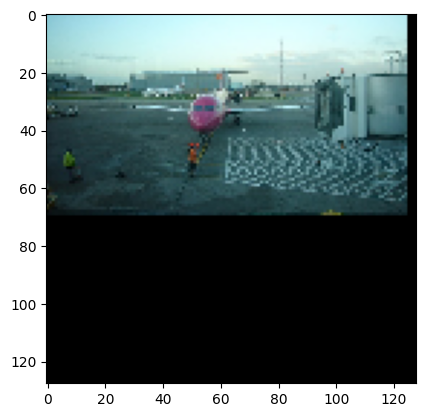

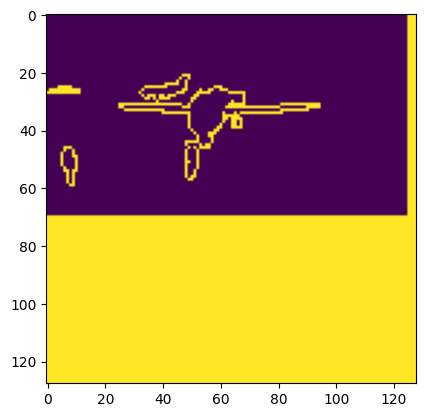

tensor([[  0,   0,   0,  ..., 255, 255, 255],
        [  0,   0,   0,  ..., 255, 255, 255],
        [  0,   0,   0,  ..., 255, 255, 255],
        ...,
        [255, 255, 255,  ..., 255, 255, 255],
        [255, 255, 255,  ..., 255, 255, 255],
        [255, 255, 255,  ..., 255, 255, 255]])


In [6]:
from matplotlib import pyplot as plt

image, label = data[0]
plt.imshow(image.permute(1,2,0))
plt.show()
plt.imshow(label)
plt.show()
print(label)

Zauważ, że wartością 255 oznaczone są "krawędzie" pomiędzy właściwymi etykietami. Etykieta 255 nie powinna być brana pod uwagę przy wyliczaniu kosztu i metryk jakości segmentacji.

# Architektura enkoder-dekoder


Możemy przejść do zdefiniowania architektury enkoder-dekoder. Achitektura ta powinna przetworzyć obraz do niższej rozdzielczości, a następnie zwiększyć jego wymiar z powrotem do oryginalnego. Podobnie jak w standardowych sieciach konwolucyjnych do klasyfikacji, przydatne jest zwiększanie liczby kanałów wraz ze zmniejszaniem rozdzielczości. Pozwala to na zachowanie informacji po downsamplingu, oraz daje możliwość wyuczenia najbardziej złożonych zależności tam gdzie jest to najbardziej istotne, czyli w warstwach operujących na najniższej rozdzielczości gdzie pole recepcyjne filtra obejmuje największy fragment obrazu. Przy upsamplingu, liczba kanałów typowo będzie się zmniejszać. Dodatkowo, skrótowe połączenia według schematu: pierwsza warstwa do ostatniej, druga do przedostaniej etc. są typowym elementem takich architektur.

# Zadanie 2

Zmodyfikuj strukturę sieci i funkcję forward SimpleEncoderDecoder tak, aby dodać połączenia skrótowe między warstwami o tej samej rozdzielczości.

In [7]:
from typing import List

class SimpleEncoderDecoder(torch.nn.Module):
  def __init__(self, channels, out_labels):
    super().__init__()
    self.conv_1 = torch.nn.Conv2d(3, channels[0], 3, padding=1)
    self.conv_2 = torch.nn.Conv2d(channels[0], channels[1], 3, padding=1)
    self.conv_3 = torch.nn.Conv2d(channels[1], channels[2], 3, padding=1)
    self.conv_4 = torch.nn.Conv2d(channels[2], channels[2], 3, padding=1)
    self.up_conv1 = torch.nn.ConvTranspose2d(channels[2], channels[1], 2, stride=2)
    self.up_conv2 = torch.nn.ConvTranspose2d(channels[1], channels[0], 2, stride=2)
    self.up_conv3 = torch.nn.ConvTranspose2d(channels[0], out_labels, 2, stride=2)
    self.pool = torch.nn.MaxPool2d(2)
    self.act = torch.nn.ReLU()
    self.bnorm = torch.nn.BatchNorm2d(channels[2])

  def forward(self, x):
    x = self.act(self.conv_1(x))        # (B, C0, H,   W)
    x = self.pool(x)                    # (B, C0, H/2, W/2)
    skip1 = x                           # zapisz: C0, H/2 — połączy się z up_conv2

    x = self.act(self.conv_2(x))        # (B, C1, H/2, W/2)
    x = self.pool(x)                    # (B, C1, H/4, W/4)
    skip2 = x                           # zapisz: C1, H/4 — połączy się z up_conv1

    x = self.act(self.conv_3(x))        # (B, C2, H/4, W/4)
    x = self.pool(x)                    # (B, C2, H/8, W/8)
    x = self.bnorm(x)
    x = self.act(self.conv_4(x))        # (B, C2, H/8, W/8)

    x = self.act(self.up_conv1(x)) + skip2   # (B, C1, H/4, W/4) + (B, C1, H/4, W/4)
    x = self.act(self.up_conv2(x)) + skip1   # (B, C0, H/2, W/2) + (B, C0, H/2, W/2)
    x = self.act(self.up_conv3(x))           # (B, out_labels, H, W)
    return x

Zweryfikuj działanie sieci:

In [13]:
model = SimpleEncoderDecoder([32,64,128], 21).cuda()

dummy_data = torch.zeros((32,3,64,64)).cuda()

assert(model(dummy_data).shape==(32,21,64,64))

# Zadanie 3

Zdefinuj kod pętli uczącej i validacji, pamiętając że wartości 255 powinny być ignorowane. Funkcją kosztu ma być entropia krzyżowa na poziomie pikseli.

Standardowa metryka accuracy może być zafałszowana przez nizbalansowanie między klasami tła a obiektów. Do validate, względem poprzednich laboratoriów, dodaj więc wyliczanie metryki Intersection over Union (IoU). (Teraz powinna ona zwracać trójkę (koszt, accuracy, IoU))

In [14]:
from typing import Tuple
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn
import torch
import numpy as np

def validate(
    model: nn.Module,
    loss_fn: torch.nn.CrossEntropyLoss,
    dataloader: DataLoader
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    model.eval()
    total_loss = 0.0
    correct = 0
    total_pixels = 0

    intersections = torch.zeros(2, device='cuda')
    unions = torch.zeros(2, device='cuda')

    # Dla metryki F1 (Macro)
    tps = torch.zeros(2, device='cuda')
    fps = torch.zeros(2, device='cuda')
    fns = torch.zeros(2, device='cuda')

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.cuda(), y.cuda()
            out = model(x)
            loss = loss_fn(out, y)
            total_loss += loss.item()

            preds = torch.argmax(out, dim=1)
            valid_mask = y != 255

            # Accuracy
            correct += ((preds == y) & valid_mask).sum().item()
            total_pixels += valid_mask.sum().item()

            # IoU i F1 dla wszystkich klas (0: tło, 1: obiekt)
            for c in range(2):
                pred_c = (preds == c) & valid_mask
                target_c = (y == c) & valid_mask

                intersections[c] += (pred_c & target_c).sum()
                unions[c] += (pred_c | target_c).sum()

                tps[c] += (pred_c & target_c).sum()
                fps[c] += (pred_c & ~target_c).sum()
                fns[c] += (~pred_c & target_c).sum()

    avg_loss = total_loss / len(dataloader)
    acc = correct / total_pixels if total_pixels > 0 else 0.0
    ious = intersections / (unions + 1e-8)
    mIoU = ious.mean().item()

    precisions = tps / (tps + fps + 1e-8)
    recalls = tps / (tps + fns + 1e-8)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    macro_f1 = f1s.mean().item()

    return torch.tensor(avg_loss), torch.tensor(acc), torch.tensor(mIoU), torch.tensor(macro_f1)

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: bool = True
):
    history = {
        'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_miou': [], 'val_f1': []
    }
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x, y in train_dl:
            x, y = x.cuda(), y.cuda()
            optimiser.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimiser.step()
            train_loss += loss.item()

        train_loss /= len(train_dl)
        val_loss, val_acc, val_miou, val_f1 = validate(model, loss_fn, val_dl)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss.item())
        history['val_acc'].append(val_acc.item())
        history['val_miou'].append(val_miou.item())
        history['val_f1'].append(val_f1.item())

        if print_metrics:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val mIoU: {val_miou:.4f} | Val F1: {val_f1:.4f}")

    return history


Wyucz sieć na danych z VOCSegmentation.

Uwaga: VOCSegmentation to dość trudny zbiór, nie trzeba tu osiągać wyjątkowo dobrych wyników.



In [15]:
model_simple = SimpleEncoderDecoder([32,64,128], 2).cuda()

loss = torch.nn.CrossEntropyLoss(ignore_index=255)
train_dl = DataLoader(data, batch_size=32, shuffle=True)
test_dl = DataLoader(test_data, batch_size=32)
optimizer = optim.Adam(model_simple.parameters())

print("Uczenie modelu SimpleEncoderDecoder...")
history_simple = fit(model_simple, optimizer, loss, train_dl, test_dl, 50, True)

Uczenie modelu SimpleEncoderDecoder...
Epoch 1/50 | Train Loss: 0.5516 | Val Loss: 0.5151 | Val Acc: 0.7329 | Val mIoU: 0.3664 | Val F1: 0.4229
Epoch 2/50 | Train Loss: 0.4909 | Val Loss: 0.5620 | Val Acc: 0.7156 | Val mIoU: 0.4464 | Val F1: 0.5755
Epoch 3/50 | Train Loss: 0.4713 | Val Loss: 0.4760 | Val Acc: 0.7565 | Val mIoU: 0.4705 | Val F1: 0.5924
Epoch 4/50 | Train Loss: 0.4676 | Val Loss: 0.4827 | Val Acc: 0.7515 | Val mIoU: 0.4406 | Val F1: 0.5485
Epoch 5/50 | Train Loss: 0.4590 | Val Loss: 0.4822 | Val Acc: 0.7600 | Val mIoU: 0.5061 | Val F1: 0.6404
Epoch 6/50 | Train Loss: 0.4538 | Val Loss: 0.6318 | Val Acc: 0.7426 | Val mIoU: 0.3979 | Val F1: 0.4789
Epoch 7/50 | Train Loss: 0.4544 | Val Loss: 0.4543 | Val Acc: 0.7681 | Val mIoU: 0.5272 | Val F1: 0.6643
Epoch 8/50 | Train Loss: 0.4466 | Val Loss: 0.4664 | Val Acc: 0.7626 | Val mIoU: 0.5122 | Val F1: 0.6473
Epoch 9/50 | Train Loss: 0.4439 | Val Loss: 0.4609 | Val Acc: 0.7650 | Val mIoU: 0.5342 | Val F1: 0.6741
Epoch 10/50 | Tr

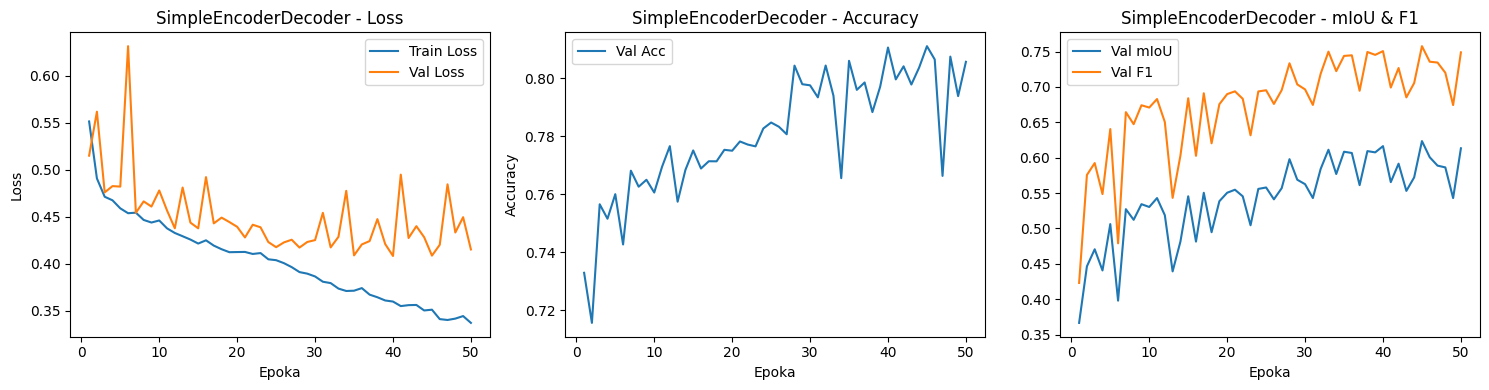

In [16]:
from matplotlib import pyplot as plt

def plot_history(history, title="Krzywe uczenia"):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['val_miou'], label='Val mIoU')
    plt.plot(epochs, history['val_f1'], label='Val F1')
    plt.title(f'{title} - mIoU & F1')
    plt.xlabel('Epoka')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_simple, "SimpleEncoderDecoder")


# Zadanie 4

Zdefiniuj parametryzowalną klasę EncoderDecoder, umożliwiającą wybór liczby warstw i liczby kanałów w poszczególnych warstwach. Klasa powinna dodawać połączenia skrótowe pomiędzy warstwami w początkowej a końcowej części architektury o tej samej rozdzielczości. Połączenia skrótowe powinny działać przez dodawanie.

Klasa powinna umożlwiać wybór pomiędzy upsamplingiem z wykorzsytaniem `ConvTranspose2D` a `torch.nn.Upsample`. Sprawdź wyniki tej drugiej opcji z parametrami analogicznymi do testów `SimpleEncoderDecoder` na segmentacji VOC.



In [19]:
from typing import List

class EncoderDecoder(torch.nn.Module):
    def __init__(self, channels: List[int], out_labels: int, use_upsample: bool = False):
        super().__init__()
        self.use_upsample = use_upsample

        # Enkoder
        self.enc_convs = nn.ModuleList()
        in_channels = 3
        for c in channels:
            self.enc_convs.append(nn.Conv2d(in_channels, c, 3, padding=1))
            in_channels = c

        # Warstwa środkowa (ostatnia warstwa, najniższa rozdzielczość)
        self.mid_conv = nn.Conv2d(channels[-1], channels[-1], 3, padding=1)
        self.bnorm = nn.BatchNorm2d(channels[-1])

        # Dekoder
        self.dec_up = nn.ModuleList()
        rev_channels = channels[::-1]

        for i in range(len(rev_channels)-1):
            out_c = rev_channels[i+1]
            if not self.use_upsample:
                self.dec_up.append(nn.ConvTranspose2d(rev_channels[i], out_c, 2, stride=2))
            else:
                self.dec_up.append(nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='nearest'),
                    nn.Conv2d(rev_channels[i], out_c, 3, padding=1)
                ))

        # Ostatnia warstwa mapująca z kanałów wyjściowych na etykiety
        if not self.use_upsample:
            self.final_up = nn.ConvTranspose2d(channels[0], out_labels, 2, stride=2)
        else:
            self.final_up = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='nearest'),
                nn.Conv2d(channels[0], out_labels, 3, padding=1)
            )

        self.pool = nn.MaxPool2d(2)
        self.act = nn.ReLU()

    def forward(self, x):
        skips = []

        # Przejście przez enkoder z zachowaniem map cech do skip connections
        for i, conv in enumerate(self.enc_convs):
            x = self.act(conv(x))
            x = self.pool(x)
            if i < len(self.enc_convs) - 1:
                skips.append(x)

        x = self.bnorm(x)
        x = self.act(self.mid_conv(x))

        # Odwracamy zachowane mapy z enkodera, by łatwiej dopasować je w dekoderze
        skips = skips[::-1]

        # Przejście przez dekoder z łączeniem (skip connections przez dodawanie)
        for i, up in enumerate(self.dec_up):
            x = self.act(up(x))
            if i < len(skips):
                x = x + skips[i]

        x = self.act(self.final_up(x))
        return x


Uczenie modelu EncoderDecoder (z Upsample)...
Epoch 1/50 | Train Loss: 0.5181 | Val Loss: 0.5335 | Val Acc: 0.7329 | Val mIoU: 0.3664 | Val F1: 0.4229
Epoch 2/50 | Train Loss: 0.4778 | Val Loss: 0.4688 | Val Acc: 0.7329 | Val mIoU: 0.3664 | Val F1: 0.4230
Epoch 3/50 | Train Loss: 0.4692 | Val Loss: 0.4854 | Val Acc: 0.7329 | Val mIoU: 0.3664 | Val F1: 0.4230
Epoch 4/50 | Train Loss: 0.4846 | Val Loss: 0.4742 | Val Acc: 0.7329 | Val mIoU: 0.3664 | Val F1: 0.4229
Epoch 5/50 | Train Loss: 0.4594 | Val Loss: 0.4880 | Val Acc: 0.7329 | Val mIoU: 0.3664 | Val F1: 0.4230
Epoch 6/50 | Train Loss: 0.4576 | Val Loss: 0.4818 | Val Acc: 0.7329 | Val mIoU: 0.3665 | Val F1: 0.4230
Epoch 7/50 | Train Loss: 0.4550 | Val Loss: 0.4914 | Val Acc: 0.7329 | Val mIoU: 0.3665 | Val F1: 0.4231
Epoch 8/50 | Train Loss: 0.4489 | Val Loss: 0.4506 | Val Acc: 0.7329 | Val mIoU: 0.3665 | Val F1: 0.4231
Epoch 9/50 | Train Loss: 0.4449 | Val Loss: 0.4505 | Val Acc: 0.7329 | Val mIoU: 0.3670 | Val F1: 0.4240
Epoch 10/

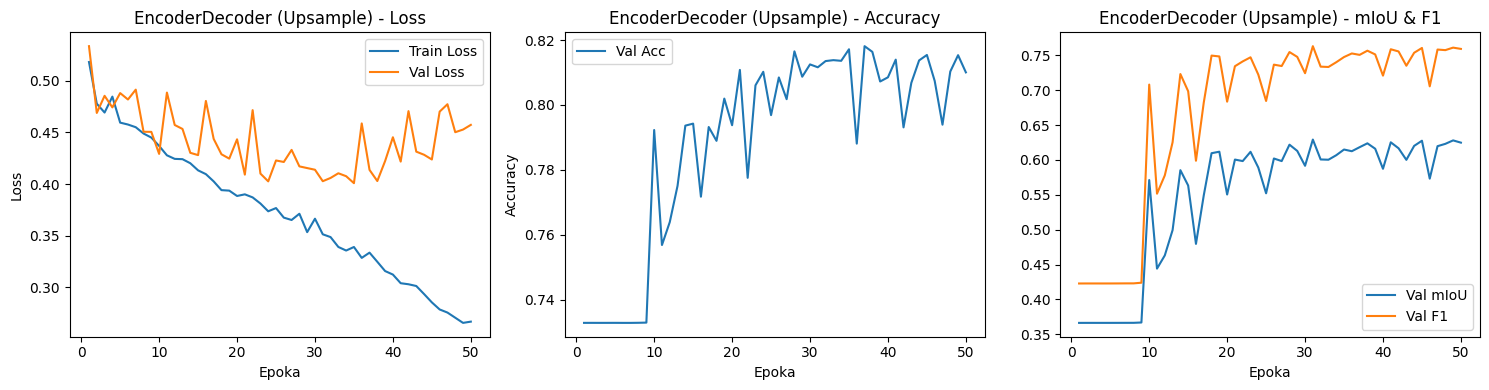

In [20]:
# Test modelu z use_upsample=True
model_upsample = EncoderDecoder([32, 64, 128], 2, use_upsample=True).cuda()
optimizer_upsample = optim.Adam(model_upsample.parameters())

print("Uczenie modelu EncoderDecoder (z Upsample)...")
history_upsample = fit(model_upsample, optimizer_upsample, loss, train_dl, test_dl, 50, True)

plot_history(history_upsample, "EncoderDecoder (Upsample)")


In [22]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params_simple = count_parameters(model_simple)
params_upsample = count_parameters(model_upsample)

print(f"Porównanie Modeli:")
print("-" * 50)
print(f"{'Model':<30} | {'Liczba Parametrów':<15}")
print("-" * 50)
print(f"{'SimpleEncoderDecoder (ConvTrans)':<30} | {params_simple:<15}")
print(f"{'EncoderDecoder (Upsample)':<30} | {params_upsample:<15}")
print("-" * 50)
print(f"Maksymalne F1 na walidacji (Simple):   {max(history_simple['val_f1']):.4f}")
print(f"Maksymalne F1 na walidacji (Upsample): {max(history_upsample['val_f1']):.4f}")
print("-" * 50)


Porównanie Modeli:
--------------------------------------------------
Model                          | Liczba Parametrów
--------------------------------------------------
SimpleEncoderDecoder (ConvTrans) | 282402         
EncoderDecoder (Upsample)      | 333922         
--------------------------------------------------
Maksymalne F1 na walidacji (Simple):   0.7576
Maksymalne F1 na walidacji (Upsample): 0.7632
--------------------------------------------------


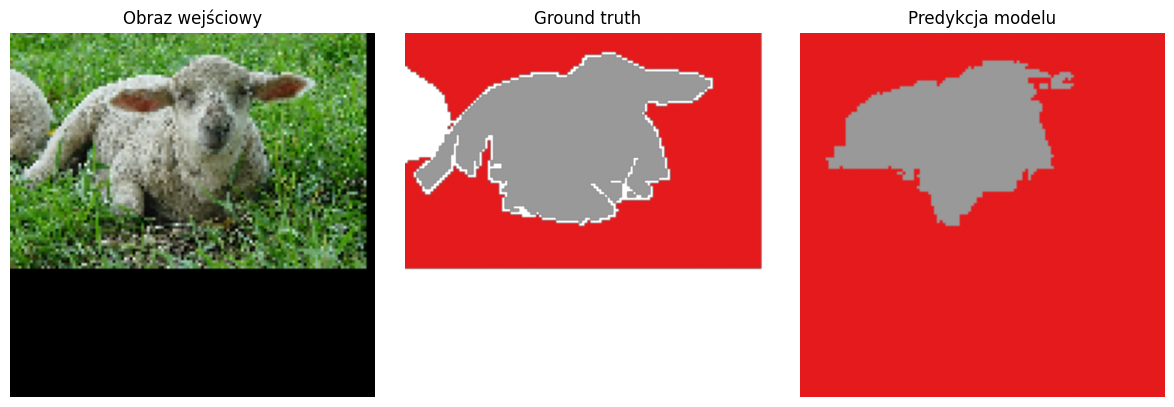

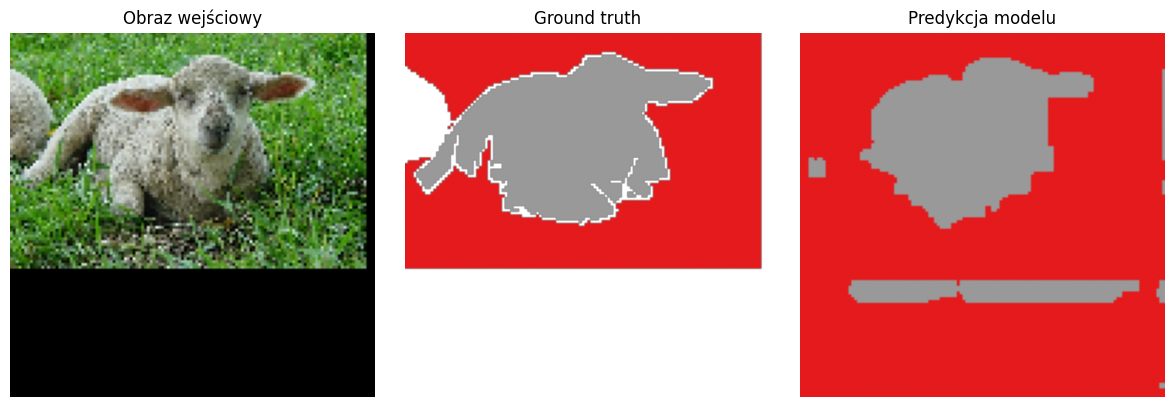

In [24]:
import matplotlib.pyplot as plt
import torch

def show_segmentation(model, dataset, idx=0):
    model.eval()
    image, label = dataset[idx]

    with torch.no_grad():
        pred = model(image.unsqueeze(0).cuda())
        pred_mask = torch.argmax(pred, dim=1).squeeze(0).cpu()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(image.permute(1, 2, 0).clamp(0, 1))
    axes[0].set_title("Obraz wejściowy")
    axes[0].axis("off")

    gt = label.float()
    gt[label == 255] = float("nan")
    axes[1].imshow(gt, cmap="Set1", vmin=0, vmax=1)
    axes[1].set_title("Ground truth")
    axes[1].axis("off")

    axes[2].imshow(pred_mask.float(), cmap="Set1", vmin=0, vmax=1)
    axes[2].set_title("Predykcja modelu")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

show_segmentation(model_simple, test_data, idx=5)
show_segmentation(model_upsample, test_data, idx=5)
